# Notebook 02 - Trend And Piecewise Growth Regimes

This notebook estimates the log real GDP trend and piecewise constant growth regimes.

In [1]:
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
_candidates = [_here, *_here.parents]
PROJECT_ROOT = next(
    path for path in _candidates
    if (path / "pyproject.toml").exists() and (path / "src" / "us_gdp_regime").exists()
)
os.chdir(PROJECT_ROOT)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

In [2]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from us_gdp_regime.config import load_config
from us_gdp_regime.pipeline import fit_models, make_figures, prepare_data
from us_gdp_regime.robustness import (
    run_criterion_sensitivity,
    run_exclusion_sensitivity,
    run_min_segment_sensitivity,
    summarize_recurring_breaks,
)
from us_gdp_regime.plotting import (
    plot_break_sensitivity,
    plot_level_overview,
    plot_trend_residuals,
)

config = load_config(Path("config/default.yaml"))
series_path = config.paths.processed_dir / "us_gdp_series.csv"
if not series_path.exists():
    prepare_data(config)
series = pd.read_csv(series_path)
series.head()

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


,year,real_gdp,gdp_growth,real_gdp_per_capita,population,source,log_real_gdp
0,1920,1.085155e+09,NaN,10152.927109,106881.0,maddison_2023,20.804989
1,1921,1.054214e+09,-2.851328,9674.880488,108964.0,maddison_2023,20.776061
2,1922,1.105913e+09,4.904101,10009.715277,110484.0,maddison_2023,20.823937
3,1923,1.244264e+09,12.510058,11071.242978,112387.0,maddison_2023,20.941810
4,1924,1.274654e+09,2.442424,11126.712983,114558.0,maddison_2023,20.965941


## Raw Real GDP And Log Real GDP

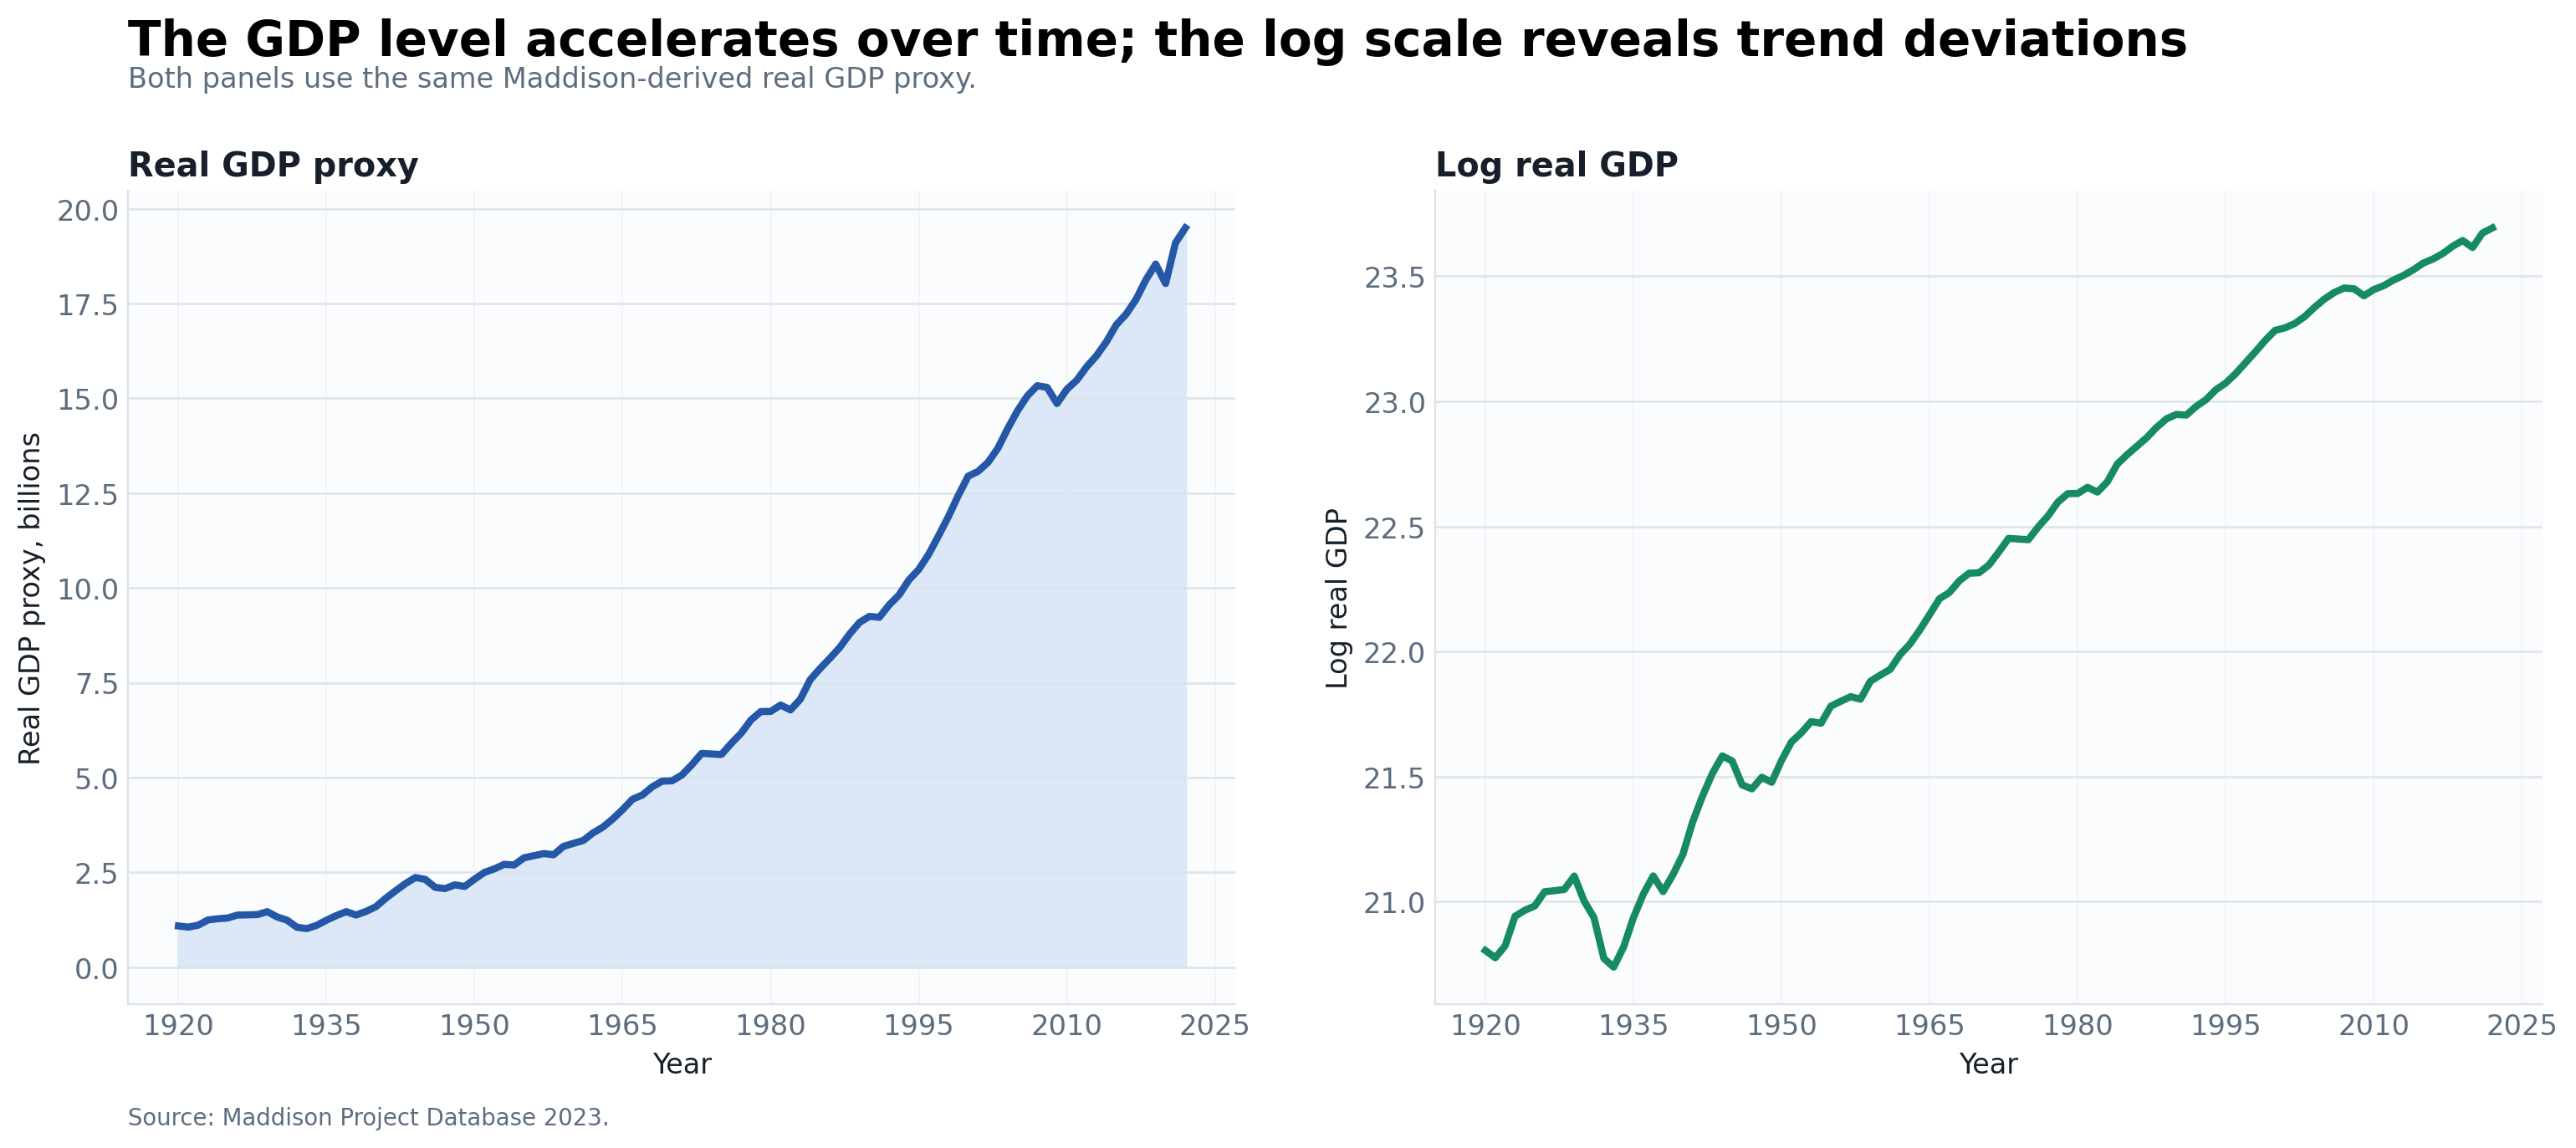

In [3]:
level_overview_path = config.paths.figures_dir / "gdp_level_log_overview.png"
plot_level_overview(series, level_overview_path, dpi=220)
display(Image(filename=str(level_overview_path)))

## Fit Log Real GDP Trend Regression

In [4]:
model_outputs = fit_models(config)
trend = pd.read_csv(model_outputs["trend"])
trend

,intercept,slope,r_squared,annualised_growth_rate
0,-38.967841,0.031076,0.987,3.156432


The trend slope is interpreted as an average annualised exponential growth rate. It summarizes the long-run path, but it does not imply that every period grew at that speed.

## Trend Residuals

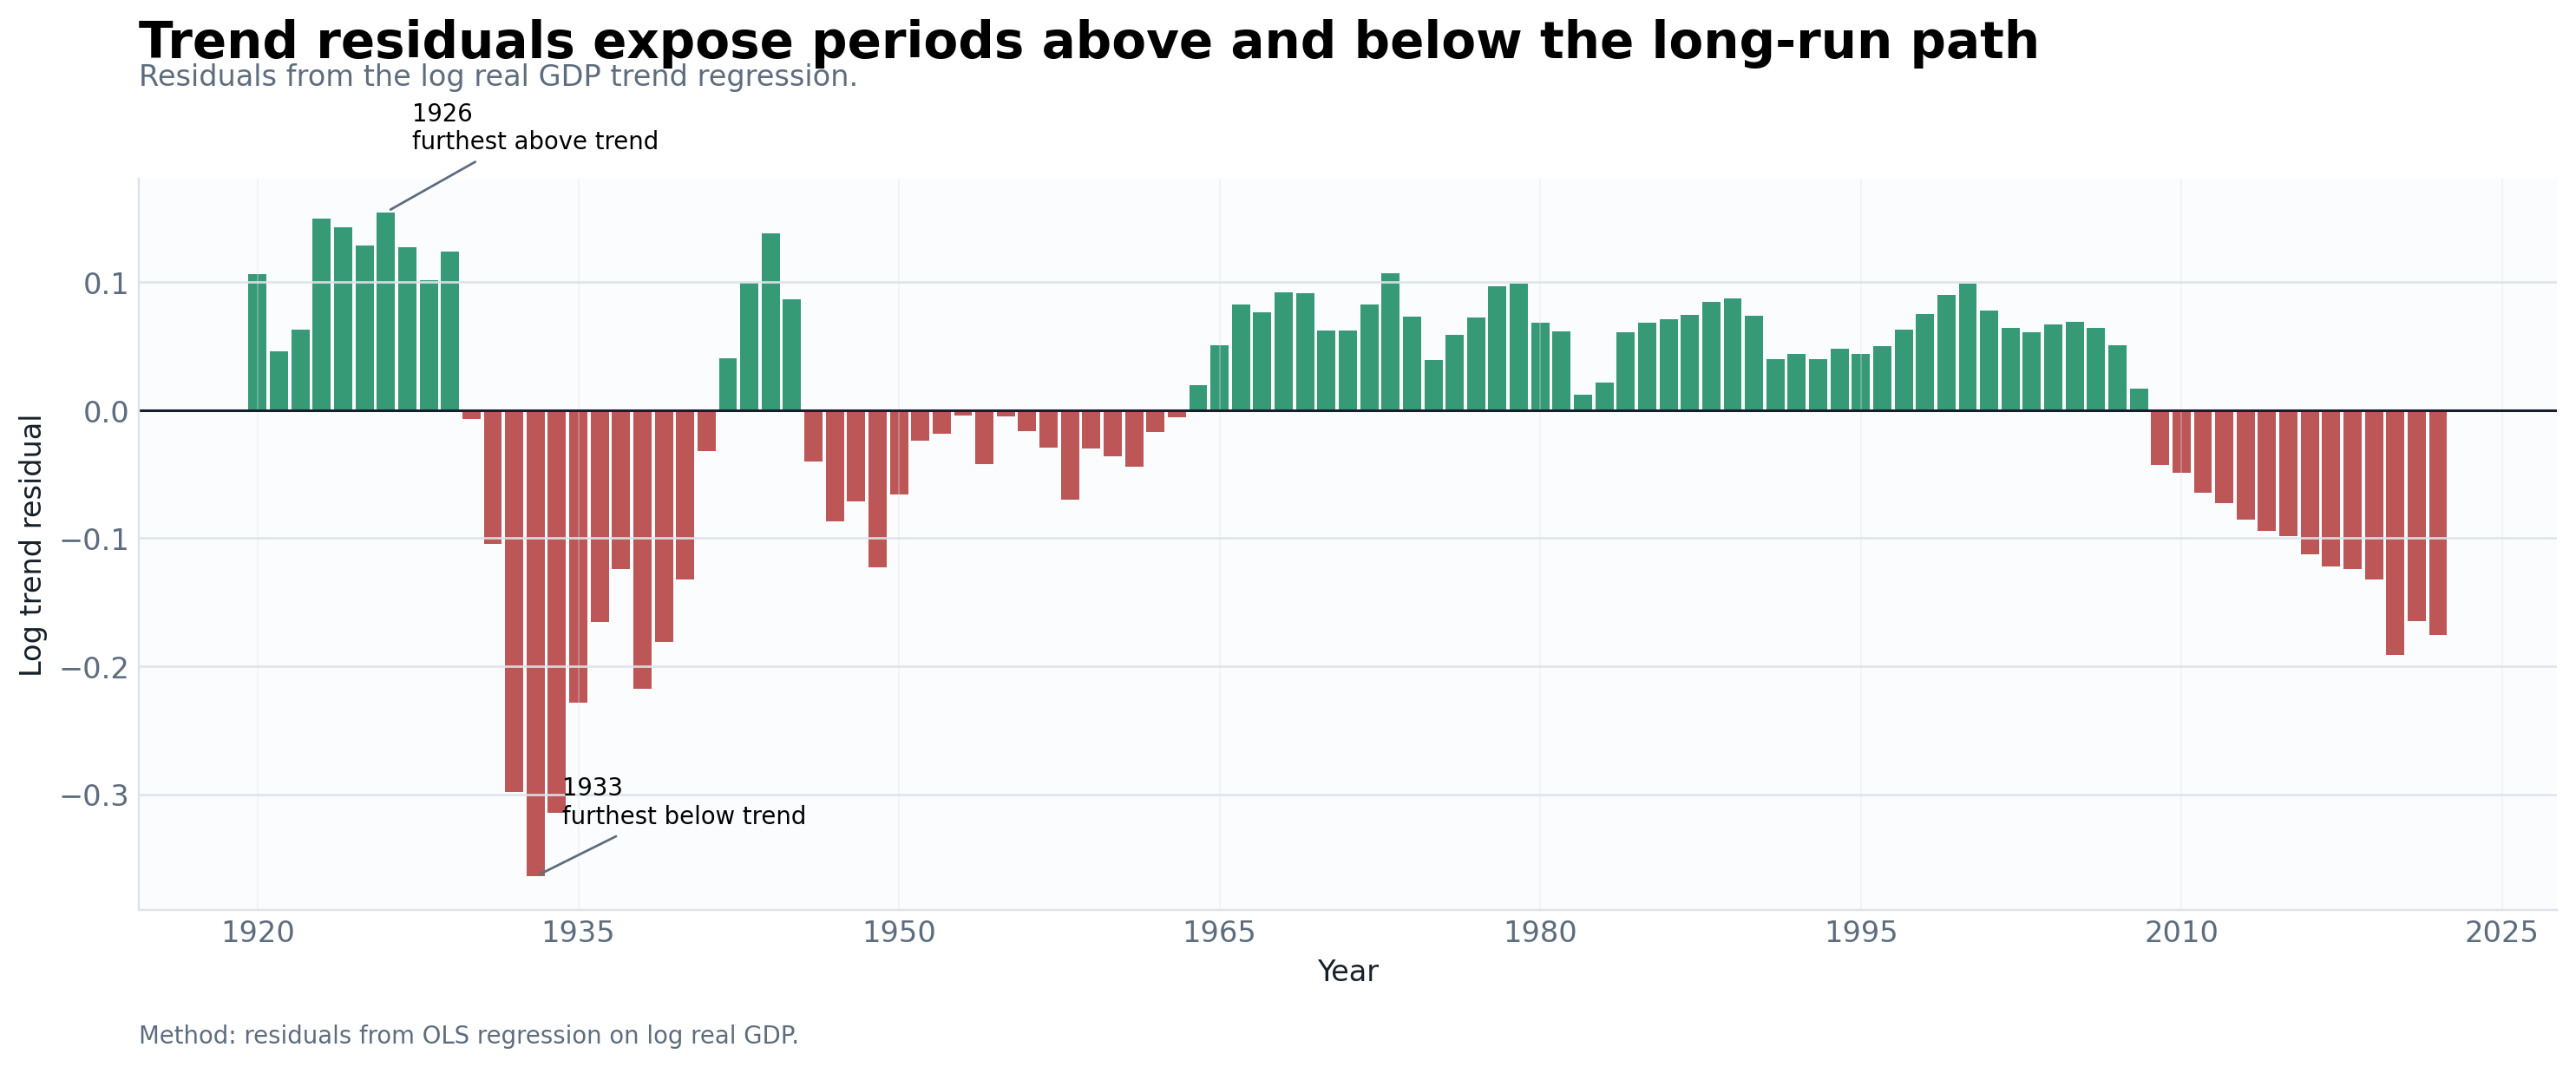

In [5]:
from us_gdp_regime.models import fit_log_trend

trend_result, trend_frame = fit_log_trend(series)
trend_residual_path = config.paths.figures_dir / "trend_residuals.png"
plot_trend_residuals(trend_frame, trend_residual_path, dpi=220)
display(Image(filename=str(trend_residual_path)))

## Fit Piecewise Constant Growth Regimes

Regime classification is based on annual growth rates, not GDP levels. GDP levels trend upward over long horizons, so above/below-mean labels on levels would mostly identify early versus late periods rather than growth performance.

In [6]:
segments = pd.read_csv(model_outputs["segments"])
segments

,segment_id,start_year,end_year,n_observations,mean_growth,long_run_mean,regime,sse
0,1,1921,1928,8,3.188583,2.968201,above_mean,151.247028
1,2,1929,1933,5,-5.776430,2.968201,below_mean,233.248676
2,3,1934,1944,11,8.096041,2.968201,above_mean,270.197092
3,4,1945,1949,5,-1.981110,2.968201,below_mean,96.136868
4,5,1950,2022,73,3.109303,2.968201,above_mean,413.479715


## Selected Breakpoints

In [7]:
break_years = segments["end_year"].iloc[:-1].tolist()
break_years

[1928, 1933, 1944, 1949]

## Article Figures

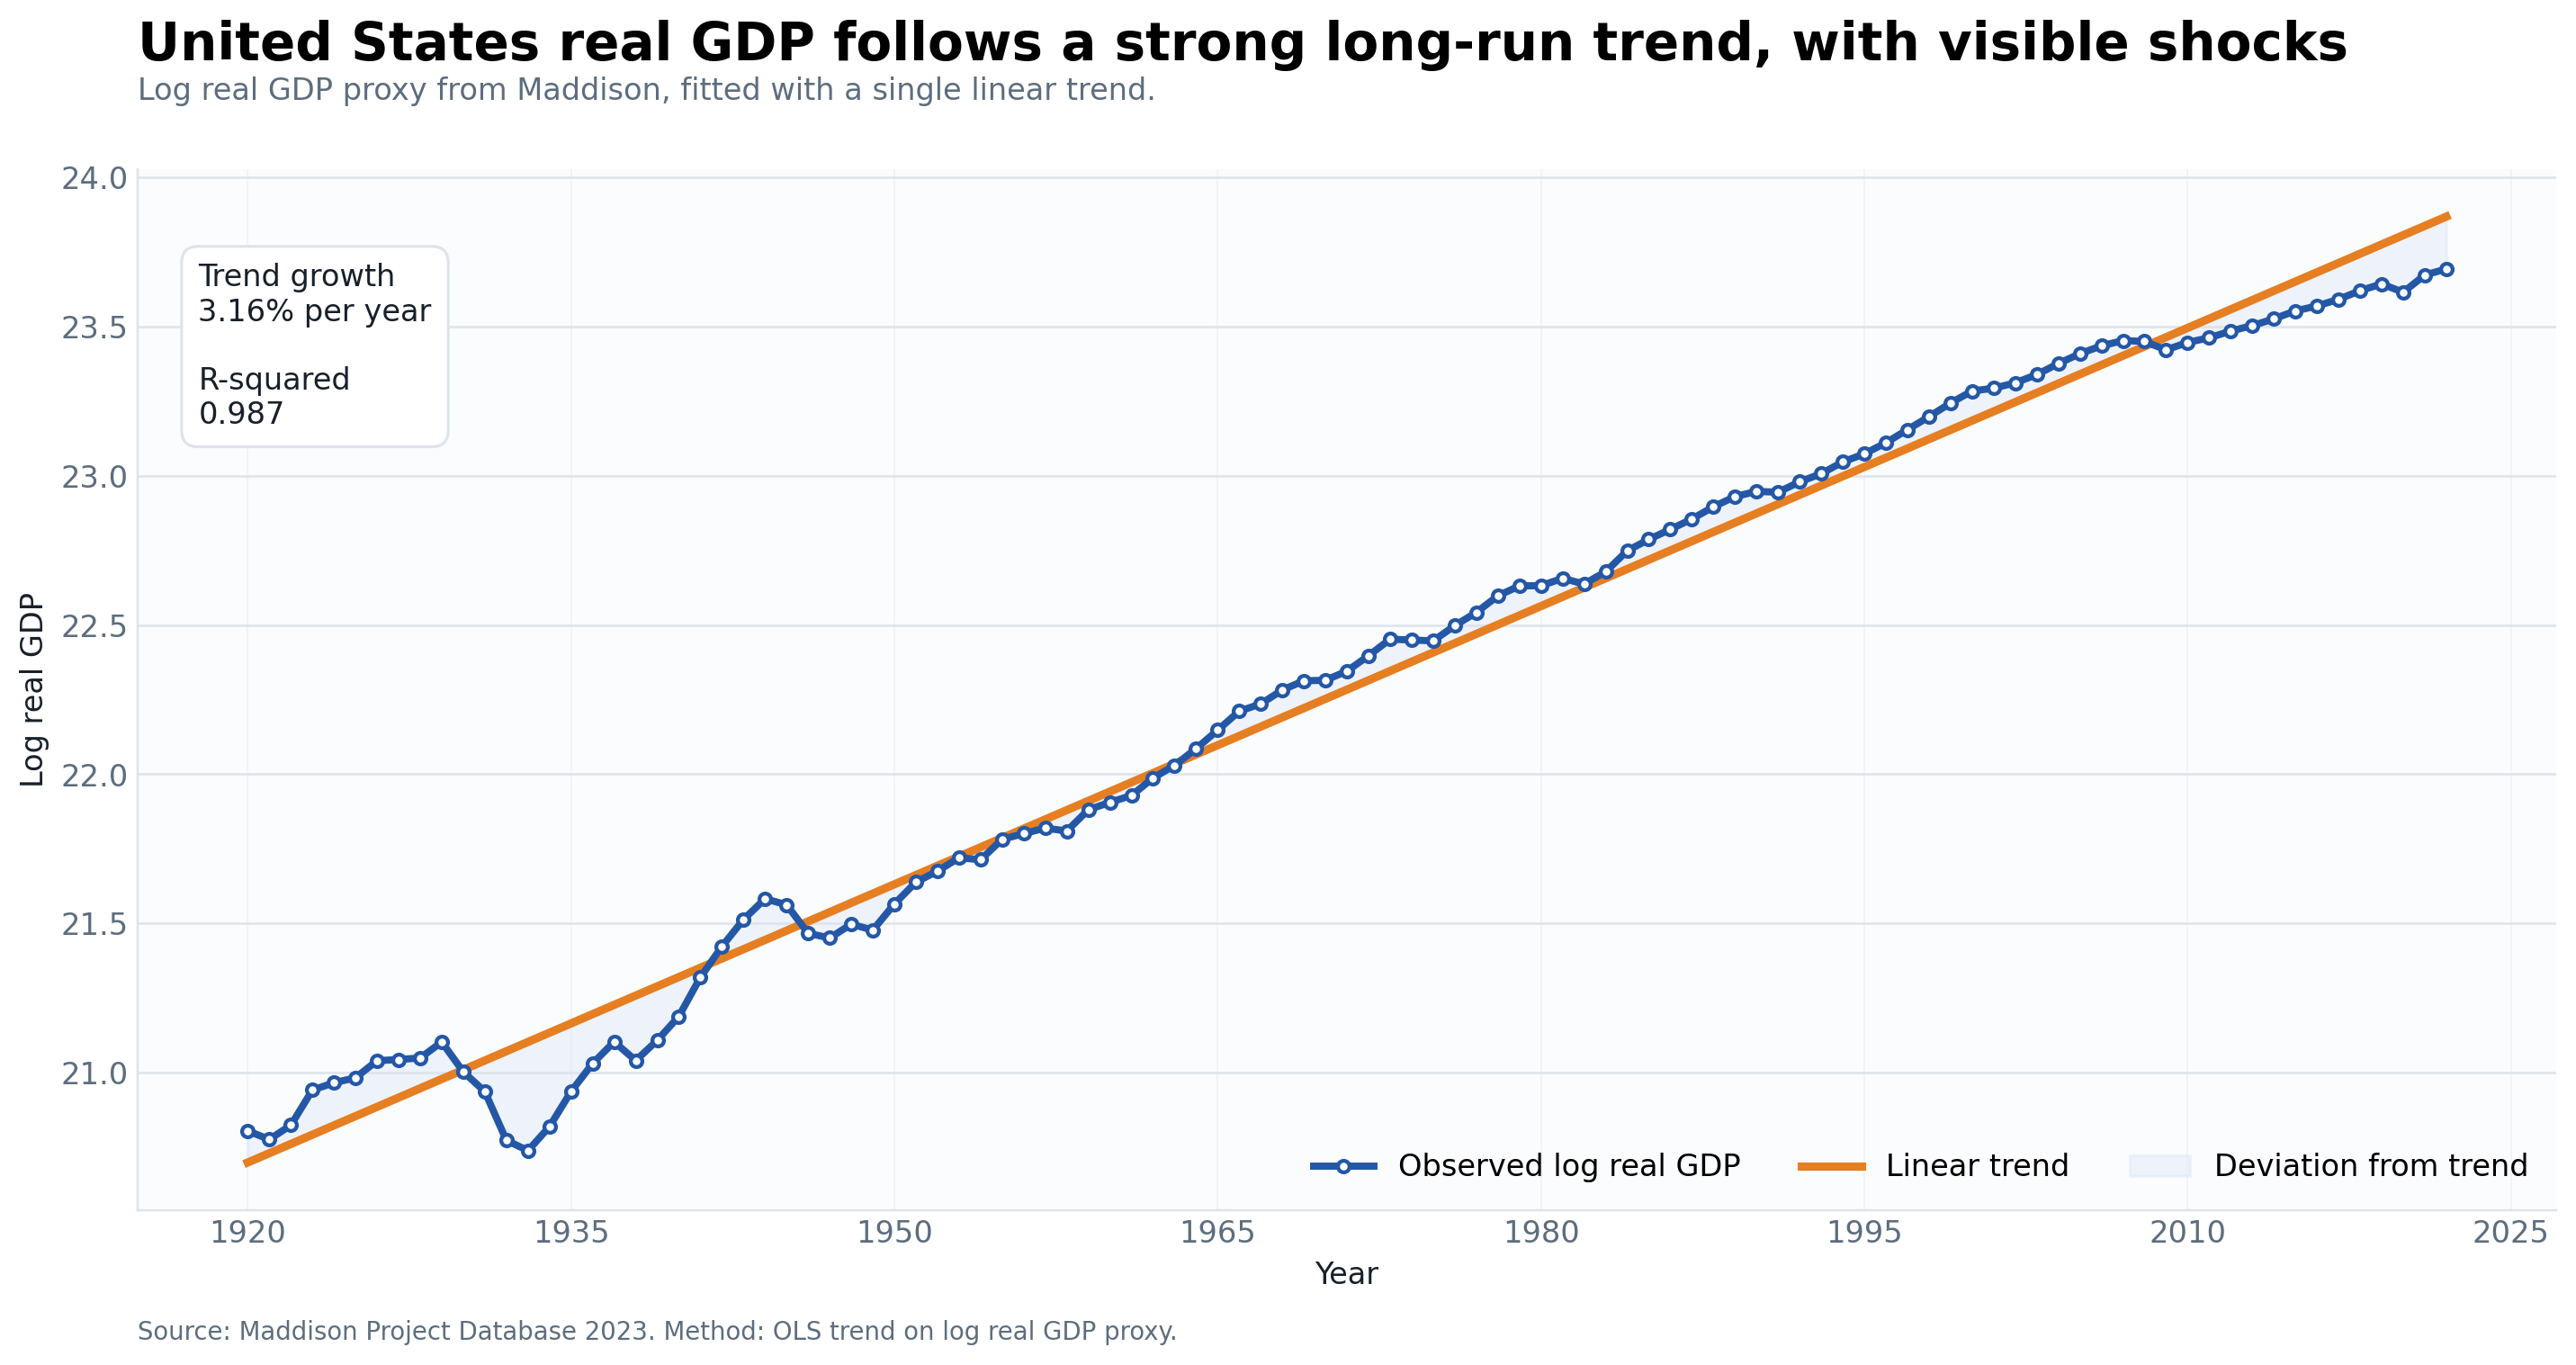

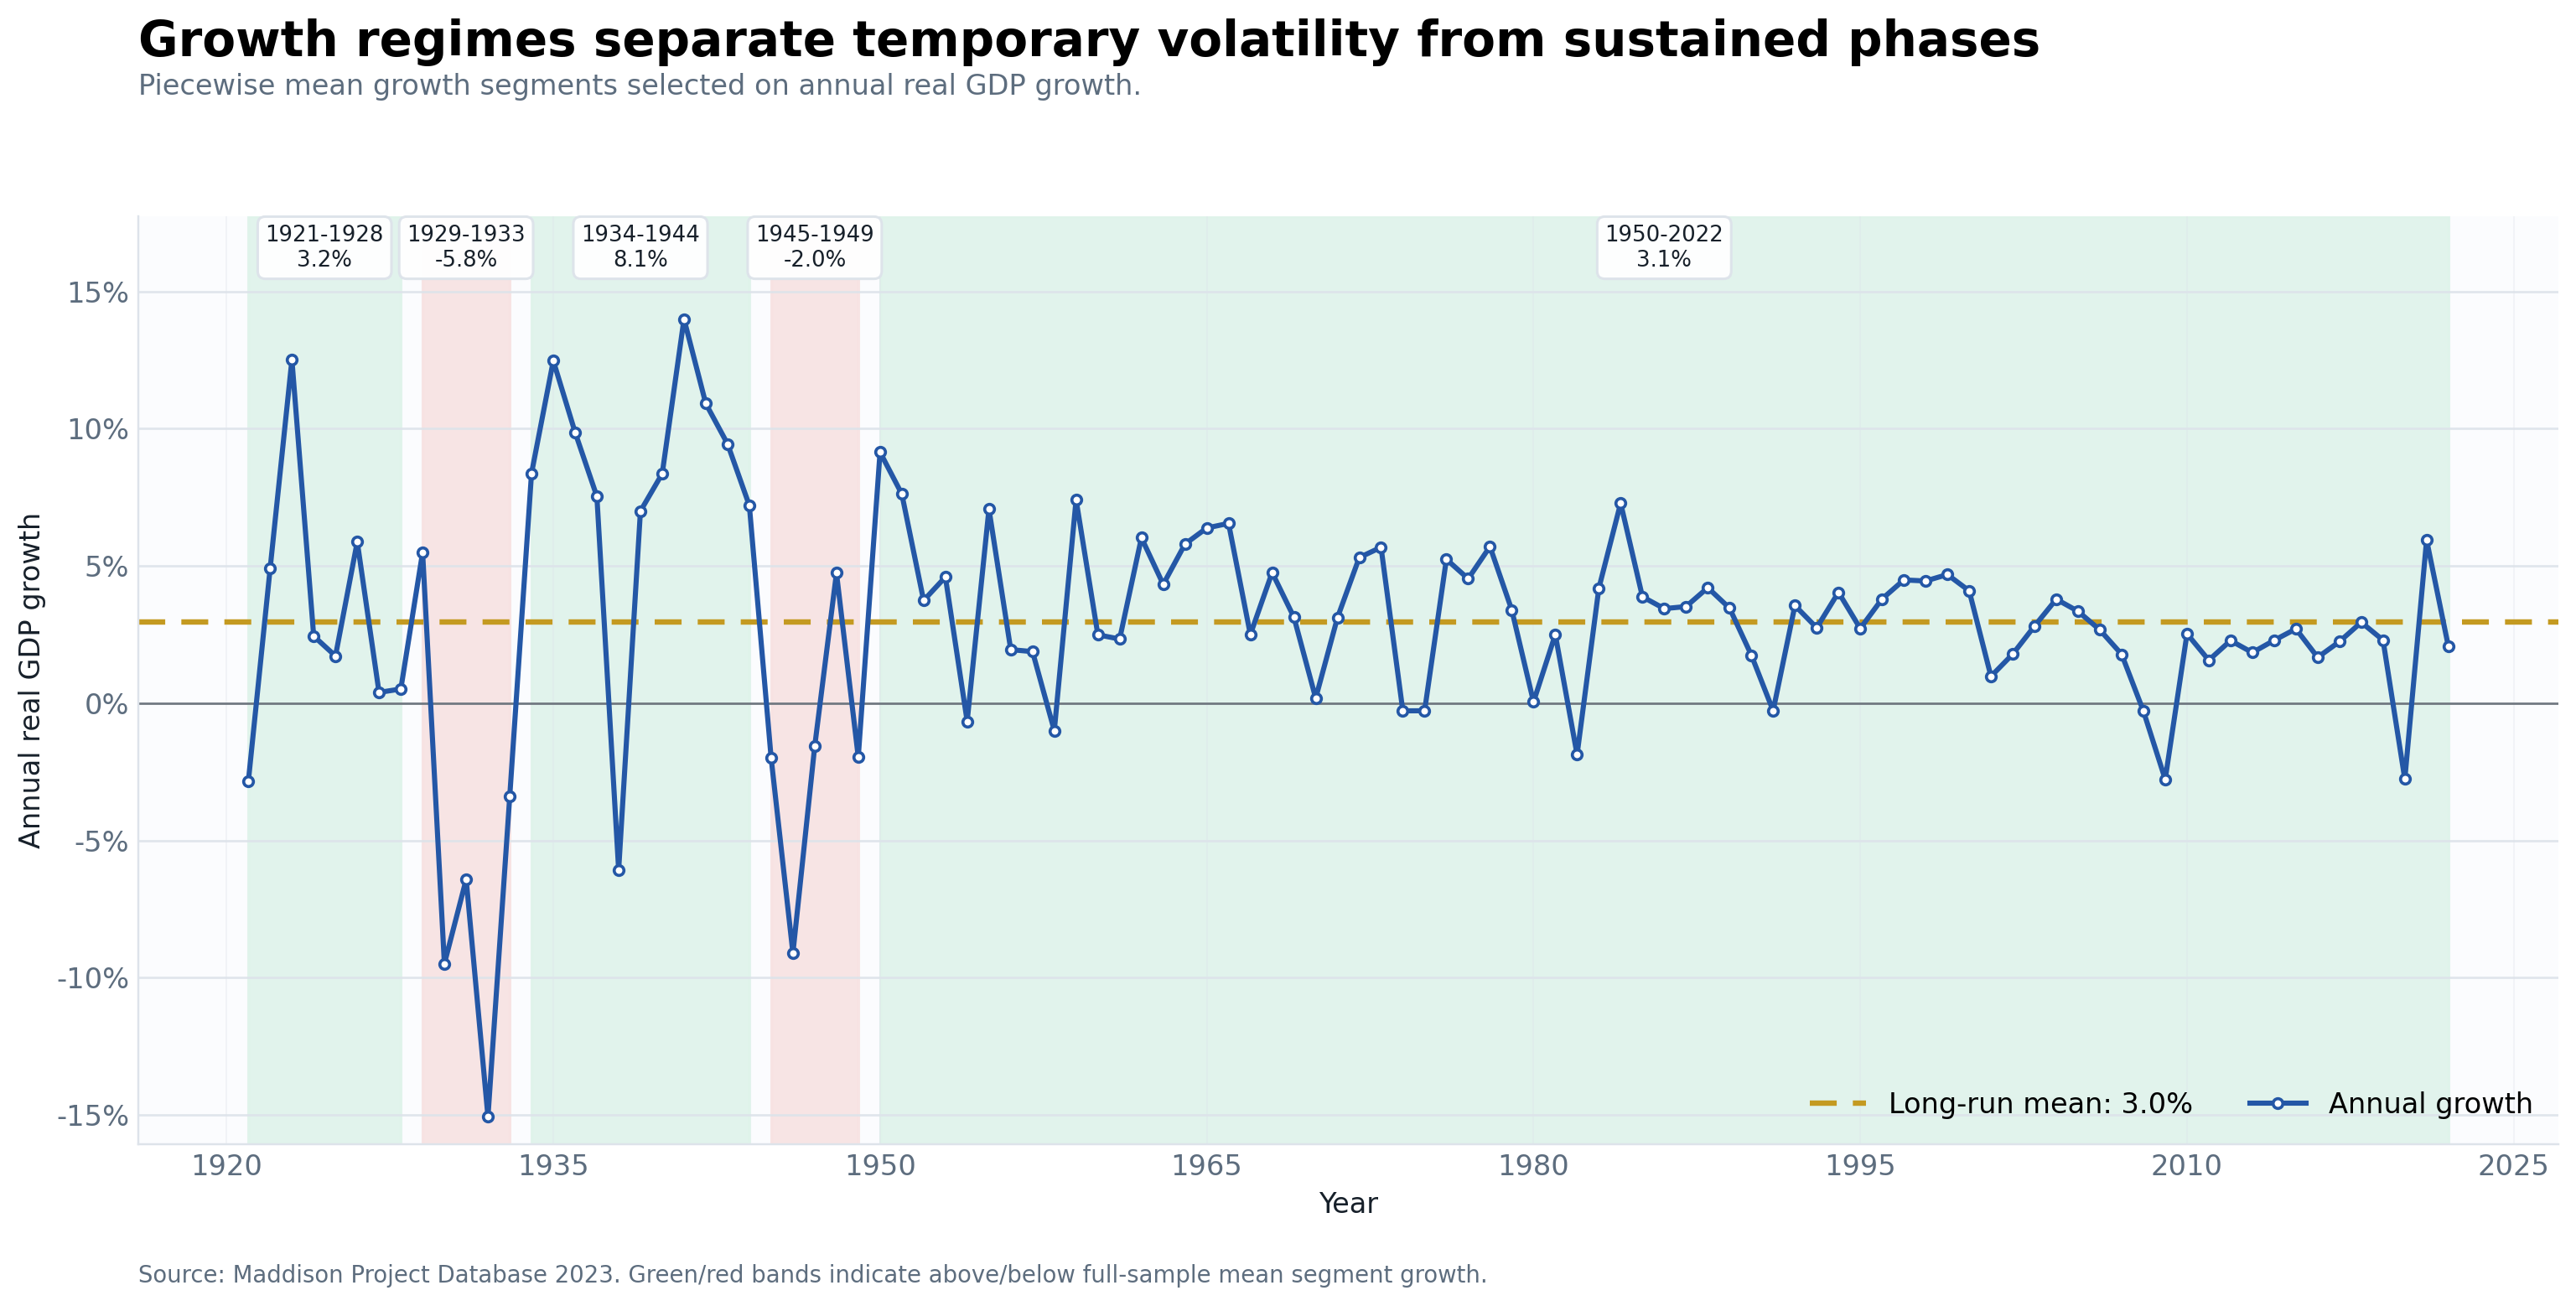

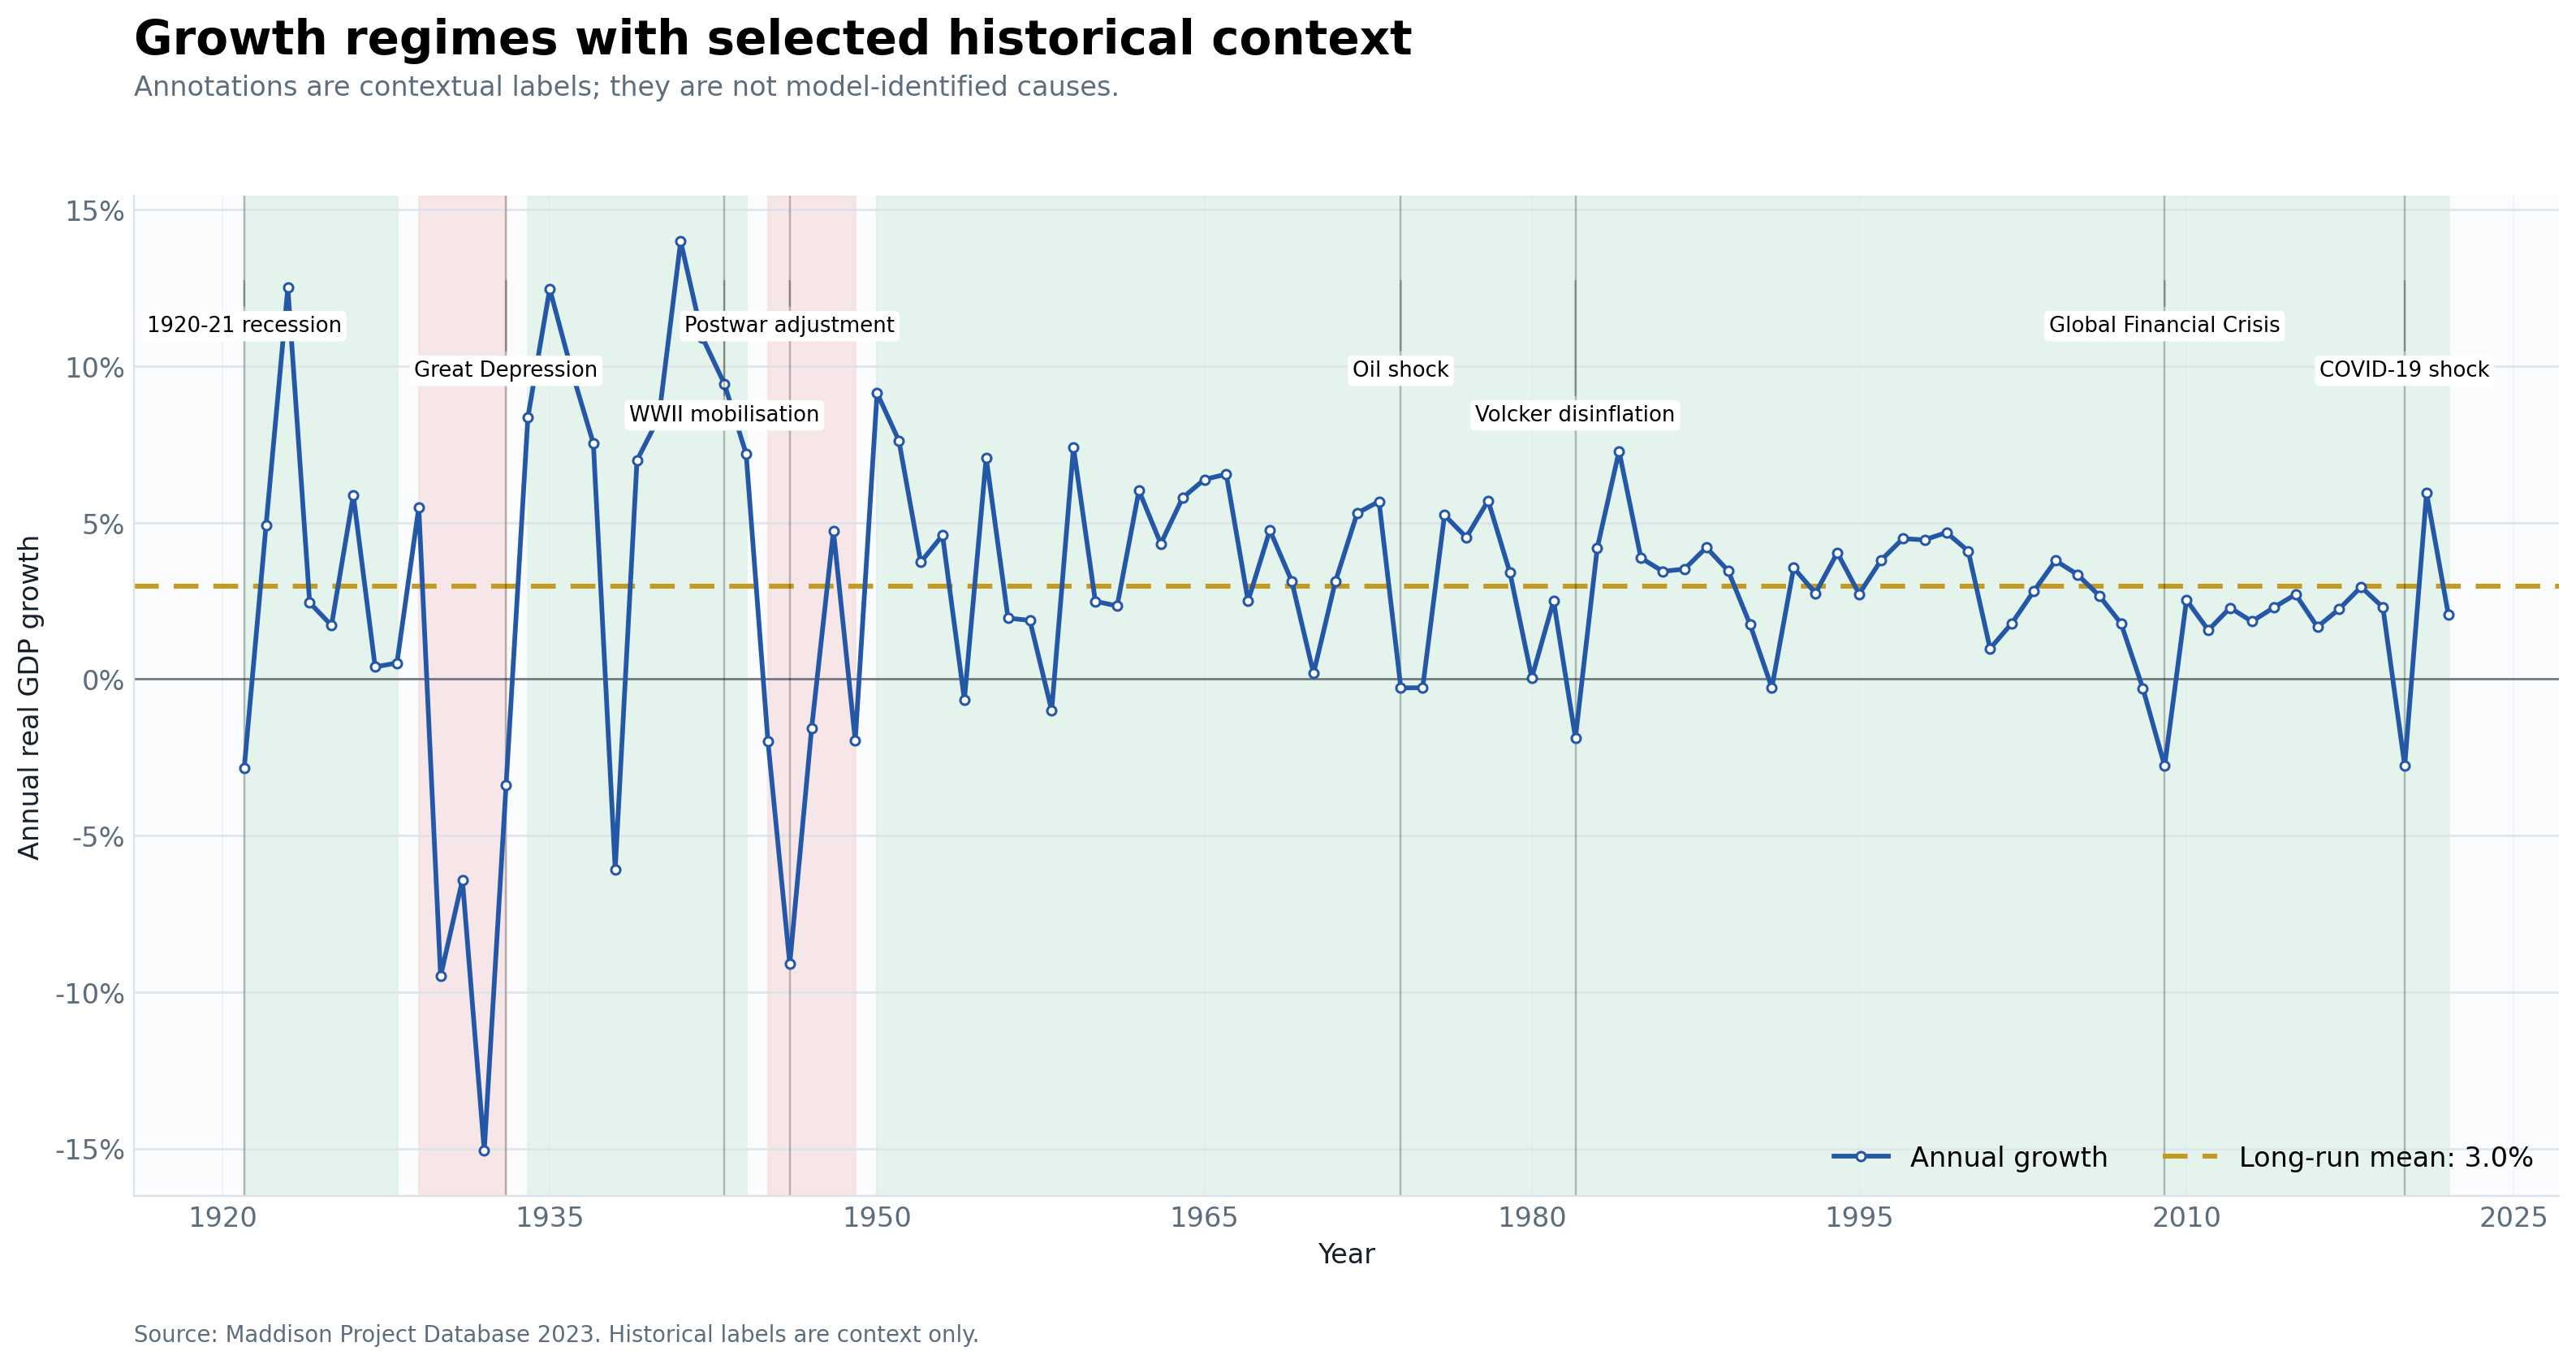

{'trend_figure': WindowsPath('figures/log_real_gdp_trend.png'),
 'regimes_figure': WindowsPath('figures/gdp_growth_regimes.png'),
 'annotated_regimes_figure': WindowsPath('figures/gdp_growth_regimes_annotated.png')}

In [8]:
figure_outputs = make_figures(config)
for key in ["trend_figure", "regimes_figure", "annotated_regimes_figure"]:
    display(Image(filename=str(figure_outputs[key])))
figure_outputs

## Sensitivity Analysis

In [9]:
min_size_results = run_min_segment_sensitivity(series, [4, 5, 7, 10], criterion="bic", max_breaks=config.model.max_breaks)
criterion_results = run_criterion_sensitivity(series, criteria=("bic", "aic"), min_segment_size=config.model.min_segment_size, max_breaks=config.model.max_breaks)
exclude_wwii = run_exclusion_sensitivity(series, [(1941, 1945)], criterion=config.model.criterion, min_segment_size=config.model.min_segment_size, max_breaks=config.model.max_breaks)
robustness = pd.concat([min_size_results, criterion_results, exclude_wwii], ignore_index=True)
robustness_path = config.paths.models_dir / "regime_robustness.csv"
robustness.to_csv(robustness_path, index=False)
robustness.head()

,scenario_id,criterion,min_segment_size,excluded_years,segment_id,start_year,end_year,mean_growth,regime
0,min_segment_size_4,bic,4,,1,1921,1929,3.444682,above_mean
1,min_segment_size_4,bic,4,,2,1930,1933,-8.593907,below_mean
2,min_segment_size_4,bic,4,,3,1934,1944,8.096041,above_mean
3,min_segment_size_4,bic,4,,4,1945,1949,-1.981110,below_mean
4,min_segment_size_4,bic,4,,5,1950,2022,3.109303,above_mean


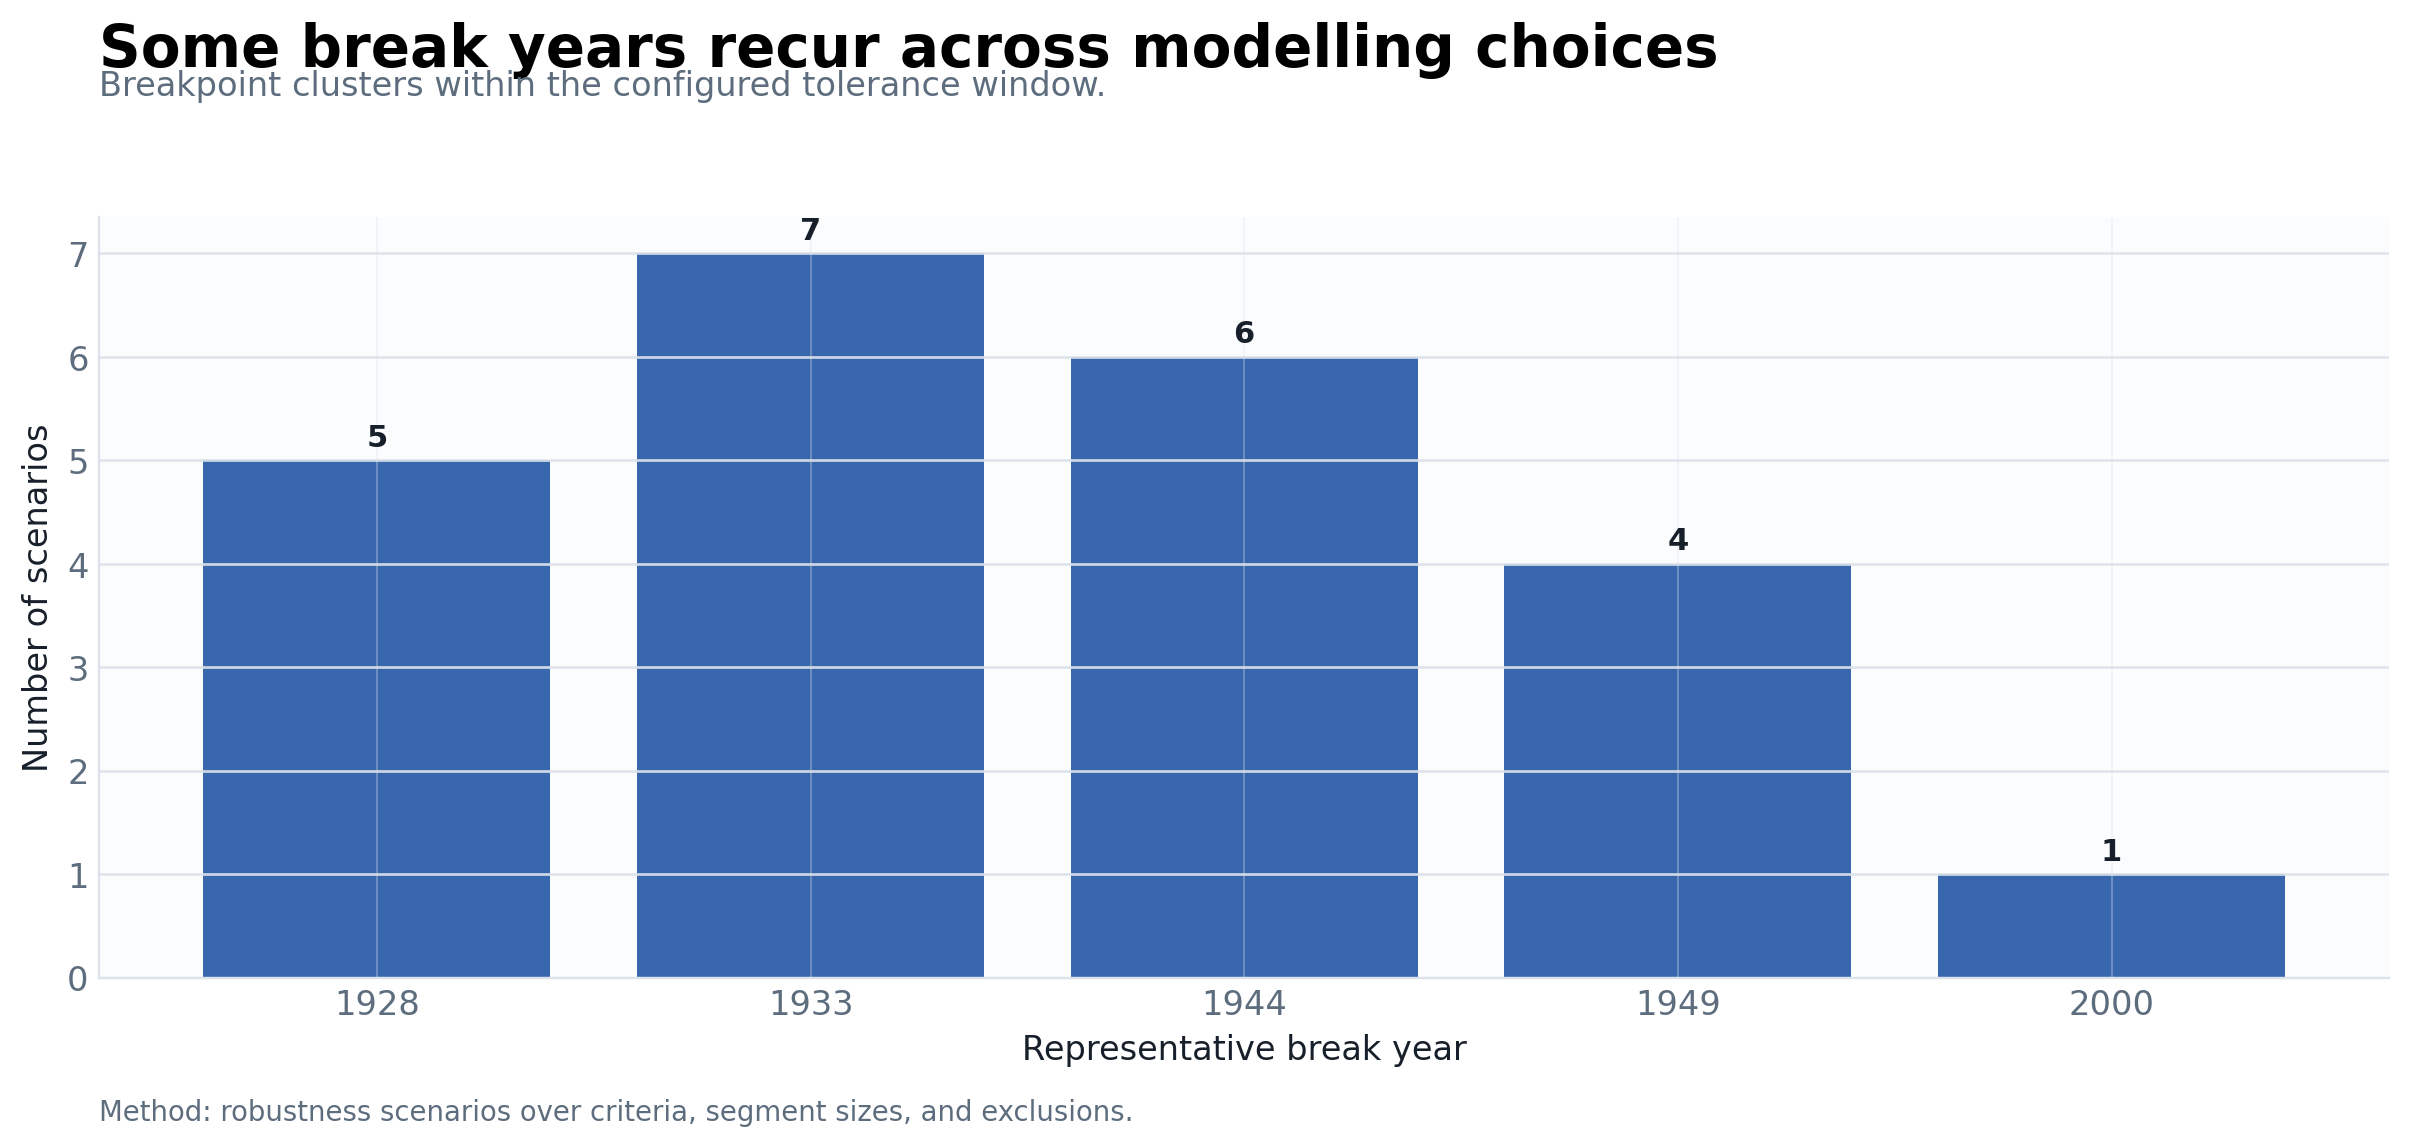

,cluster_id,representative_break_year,min_break_year,max_break_year,n_breaks,n_scenarios,scenarios
0,1,1928,1928,1929,5,5,"criterion_aic,criterion_bic,exclude_1941,1942,..."
1,2,1933,1933,1933,7,7,"criterion_aic,criterion_bic,exclude_1941,1942,..."
2,3,1944,1944,1944,6,6,"criterion_aic,criterion_bic,min_segment_size_1..."
3,4,1949,1949,1949,4,4,"criterion_aic,criterion_bic,min_segment_size_4..."
4,5,2000,2000,2000,1,1,criterion_aic


In [10]:
recurring = summarize_recurring_breaks(robustness, tolerance=2)
recurring_path = config.paths.models_dir / "recurring_break_years.csv"
recurring.to_csv(recurring_path, index=False)
if not recurring.empty:
    sensitivity_path = config.paths.figures_dir / "breakpoint_sensitivity.png"
    plot_break_sensitivity(recurring, sensitivity_path, dpi=220)
    display(Image(filename=str(sensitivity_path)))
recurring

## Sensitivity Interpretation

Stable break years are those that recur across criteria, minimum segment sizes, or exclusion scenarios. Unstable break years should not be overinterpreted. The configured BIC model remains the default article model because BIC penalizes extra short regimes more strongly than AIC.